In [1]:
# Install libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import shap

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
# Load data
job_fraud_df = pd.read_csv("/content/fake_job_postings.csv.zip")

In [3]:
job_fraud_df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [4]:
job_fraud_df.tail()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
17875,17876,Account Director - Distribution,"CA, ON, Toronto",Sales,NaN,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Sales,0
17876,17877,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,0
17877,17878,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",NaN,NaN,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0,0,0,Full-time,NaN,NaN,NaN,NaN,0
17878,17879,Graphic Designer,"NG, LA, Lagos",NaN,NaN,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0,0,1,Contract,Not Applicable,Professional,Graphic Design,Design,0
17879,17880,Web Application Developers,"NZ, N, Wellington",Engineering,NaN,Vend is looking for some awesome new talent to...,Who are we?Vend is an award winning web based ...,We want to hear from you if:You have an in-dep...,NaN,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Engineering,0


In [5]:
job_fraud_df.shape

(17880, 18)

In [6]:
job_fraud_df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [7]:
job_fraud_df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
job_fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [9]:
#Handling missing values

job_fraud_df.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


In [10]:
text_cols = [
    "title", "company_profile", "description",
    "requirements", "benefits"
]

cat_cols = [
    "location", "department", "employment_type",
    "required_experience", "required_education",
    "industry", "function"
]

# Fill text columns
for col in text_cols:
    job_fraud_df[col] = job_fraud_df[col].fillna("")

# Fill categorical columns
for col in cat_cols:
    job_fraud_df[col] = job_fraud_df[col].fillna("Not Specified")


In [11]:
job_fraud_df.isnull().sum()

,0
job_id,0
title,0
location,0
department,0
salary_range,15012
company_profile,0
description,0
requirements,0
benefits,0
telecommuting,0


In [12]:
#Handling values in Salary_range column

def parse_salary(salary):
    if pd.isna(salary):
        return np.nan, np.nan
    nums = re.findall(r"\d+", salary.replace(",", ""))
    if len(nums) >= 2:
        return int(nums[0]), int(nums[1])
    return np.nan, np.nan

job_fraud_df["salary_min"], job_fraud_df["salary_max"] = zip(
    *job_fraud_df["salary_range"].apply(parse_salary)
)

job_fraud_df["salary_mean"] = job_fraud_df[["salary_min", "salary_max"]].mean(axis=1)
job_fraud_df["salary_missing"] = job_fraud_df["salary_range"].isna().astype(int)


In [13]:
#Text feature engineering

job_fraud_df["combined_text"] = (
    job_fraud_df["title"] + " " +
    job_fraud_df["description"] + " " +
    job_fraud_df["requirements"] + " " +
    job_fraud_df["company_profile"] + " " +
    job_fraud_df["benefits"]
)

In [14]:
# Encoding binary columns

binary_cols = [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

In [15]:
#CATEGORICAL FEATURES

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded_cat = ohe.fit_transform(job_fraud_df[cat_cols])

In [16]:
#FINAL FEATURE SET

numeric_features = [
    "salary_mean",
    "salary_missing",
    "telecommuting",
    "has_company_logo",
    "has_questions"
]


Model building

In [17]:
X = job_fraud_df[["combined_text"] + numeric_features]
y = job_fraud_df["fraudulent"]

# Fill remaining numeric NaNs
X[numeric_features] = X[numeric_features].fillna(0)


/tmp/ipython-input-3610891919.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numeric_features] = X[numeric_features].fillna(0)


In [18]:
#TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [19]:
# PREPROCESSING PIPELINE

text_transformer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_transformer, "combined_text"),
        ("num", numeric_transformer, numeric_features)
    ]
)

In [20]:
#MODEL (CLASS IMBALANCE HANDLED)

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear"
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ]
)

In [21]:
#TRAIN MODEL

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'combined_text'),
                                                 ('num', StandardScaler(),
                                                  ['salary_mean',
                                                   'salary_missing',
                                                   'telecommuting',
                                                   'has_company_logo',
                                                   'has_questions'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

In [22]:
#EVALUATION

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", round(roc_auc, 4))


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3403
           1       0.55      0.90      0.68       173

    accuracy                           0.96      3576
   macro avg       0.77      0.93      0.83      3576
weighted avg       0.97      0.96      0.96      3576

ROC-AUC Score: 0.9881


In [23]:
#SHAP EXPLAINER (FOR EXPLAINABLE AI)

# Extract trained components
tfidf = pipeline.named_steps["preprocessor"].named_transformers_["text"]
classifier = pipeline.named_steps["classifier"]

# Transform the full training dataset using the entire preprocessor
# This ensures the input to SHAP explainer matches the features the classifier was trained on (text + numeric)
X_train_transformed = pipeline.named_steps["preprocessor"].transform(X_train)

explainer = shap.LinearExplainer(
    classifier,
    X_train_transformed, # Use the fully transformed training data
    feature_perturbation="interventional"
)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


In [24]:
#SAVE ARTIFACTS

pickle.dump(pipeline, open("model.pkl", "wb"))
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))
pickle.dump(explainer, open("explainer.pkl", "wb"))

print("\n✅ Model, Vectorizer, and SHAP Explainer saved successfully")


✅ Model, Vectorizer, and SHAP Explainer saved successfully


In [33]:
import pickle
import numpy as np
from sklearn.metrics import precision_recall_curve

pipeline = pickle.load(open("model.pkl", "rb"))

y_proba = pipeline.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

target_recall = 0.95
idx = np.where(recall >= target_recall)[0][0]

optimal_threshold = thresholds[idx]

print("Optimal Threshold:", round(optimal_threshold, 3))
print("Precision:", round(precision[idx], 3))
print("Recall:", round(recall[idx], 3))

pickle.dump(optimal_threshold, open("threshold.pkl", "wb"))

Optimal Threshold: 0.0
Precision: 0.048
Recall: 1.0


Visualization

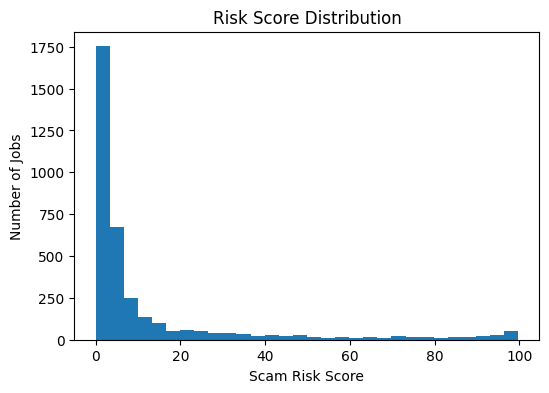

In [25]:
#Risk score distribution

plt.figure(figsize=(6,4))
plt.hist(y_proba * 100, bins=30)
plt.xlabel("Scam Risk Score")
plt.ylabel("Number of Jobs")
plt.title("Risk Score Distribution")
plt.show()


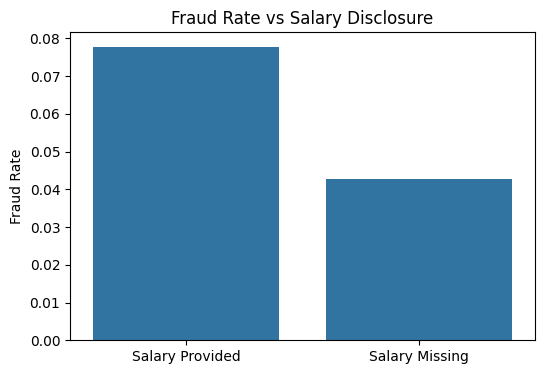

In [26]:
#Fraud rate wrt salary disclosure

import seaborn as sns
import matplotlib.pyplot as plt

salary_fraud = (
    job_fraud_df.groupby("salary_missing")["fraudulent"]
    .mean()
    .reset_index()
)

salary_fraud["salary_missing"] = salary_fraud["salary_missing"].map(
    {0: "Salary Provided", 1: "Salary Missing"}
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=salary_fraud,
    x="salary_missing",
    y="fraudulent"
)
plt.ylabel("Fraud Rate")
plt.xlabel("")
plt.title("Fraud Rate vs Salary Disclosure")
plt.show()


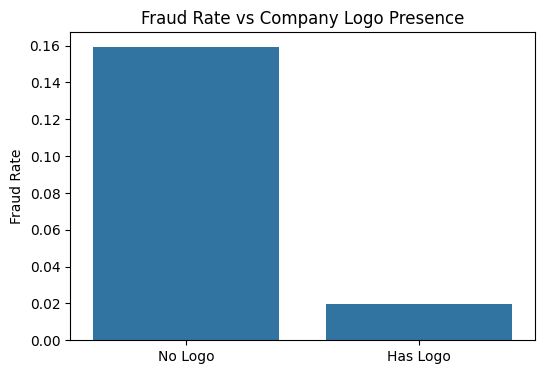

In [27]:
#Fraud rate vs company logo

logo_fraud = (
    job_fraud_df.groupby("has_company_logo")["fraudulent"]
    .mean()
    .reset_index()
)

logo_fraud["has_company_logo"] = logo_fraud["has_company_logo"].map(
    {0: "No Logo", 1: "Has Logo"}
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=logo_fraud,
    x="has_company_logo",
    y="fraudulent"
)
plt.ylabel("Fraud Rate")
plt.xlabel("")
plt.title("Fraud Rate vs Company Logo Presence")
plt.show()


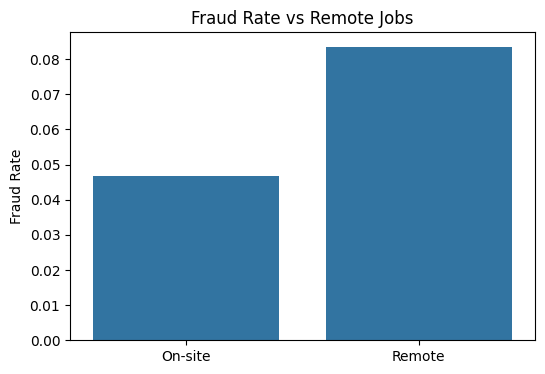

In [28]:
#Fraud rate vs telecommuting

remote_fraud = (
    job_fraud_df.groupby("telecommuting")["fraudulent"]
    .mean()
    .reset_index()
)

remote_fraud["telecommuting"] = remote_fraud["telecommuting"].map(
    {0: "On-site", 1: "Remote"}
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=remote_fraud,
    x="telecommuting",
    y="fraudulent"
)
plt.ylabel("Fraud Rate")
plt.xlabel("")
plt.title("Fraud Rate vs Remote Jobs")
plt.show()


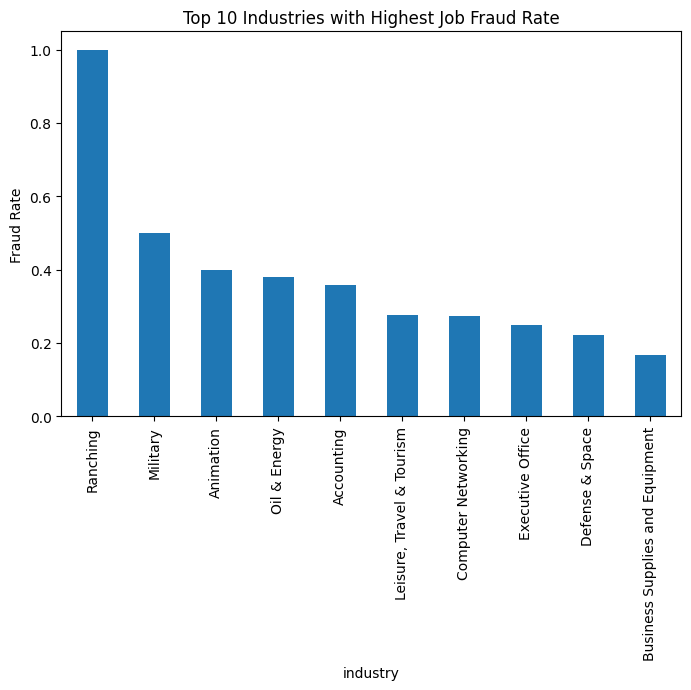

In [29]:
#Top industries with higher fraud rate

industry_fraud = (
    job_fraud_df.groupby("industry")["fraudulent"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))
industry_fraud.plot(kind="bar")
plt.ylabel("Fraud Rate")
plt.title("Top 10 Industries with Highest Job Fraud Rate")
plt.show()


In [30]:
#Feature importance

preprocessor = pipeline.named_steps["preprocessor"]
classifier = pipeline.named_steps["classifier"]

text_feature_names = (
    preprocessor
    .named_transformers_["text"]
    .get_feature_names_out()
)

numeric_feature_names = [
    "salary_mean",
    "salary_missing",
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

# Combine feature names in correct order
all_feature_names = list(text_feature_names) + numeric_feature_names

# Extract coefficients
coefficients = classifier.coef_[0]

# Create DataFrame
coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coefficients
})

top_positive = coef_df.sort_values(
    by="coefficient",
    ascending=False
).head(15)

top_negative = coef_df.sort_values(
    by="coefficient",
    ascending=True
).head(15)


In [31]:
#  Display top scam-indicating features
print("\n🔴 Top Features Increasing Scam Risk")
print(top_positive)

print("\n🟢 Top Features Indicating Genuine Jobs")
print(top_negative)


🔴 Top Features Increasing Scam Risk
          feature  coefficient
2560         link     4.642486
321      aptitude     3.896084
2845        money     3.591341
2084  high school     3.586526
1             000     3.586162
1401         earn     3.296929
1123   data entry     3.260043
1516  engineering     3.121916
4067      signing     3.033113
3011         ohio     2.946114
4320       subsea     2.857633
1792    financing     2.839819
654          cash     2.739600
2529   leveraging     2.672569
3015      oil gas     2.646035

🟢 Top Features Indicating Genuine Jobs
          feature  coefficient
4418         team    -3.030609
840     companies    -2.957775
1522      english    -2.539548
1994      growing    -2.272859
3934       search    -2.247788
452         based    -2.216621
69             50    -2.193721
3251          php    -2.121109
1287      digital    -2.057533
2697    marketing    -2.056489
3660  recruitment    -2.044394
1890          fun    -2.018663
4132     software    -1.

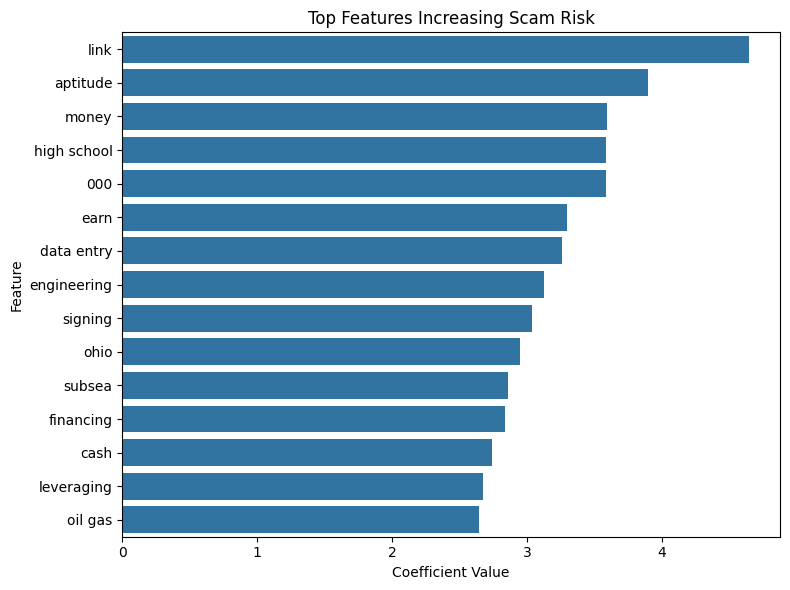

In [32]:
#  Visualization (Scam Risk Features)
plt.figure(figsize=(8,6))
sns.barplot(
    data=top_positive,
    x="coefficient",
    y="feature"
)
plt.title("Top Features Increasing Scam Risk")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()